In [11]:
SEED = 42
import numpy as np
np.random.seed(SEED)
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib

DATA_DIR = Path("../data/processed/FD001")
train_df = pd.read_csv(DATA_DIR / "train_with_rul.csv")

RUL_CAP = 125

# op3 is constant (always 100.0) in FD001 — dropped permanently
# s3 uses global scaling to preserve variance across engines
FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]   # 16 features — op3 removed

GLOBAL_SCALE_FEATURES = ["s3"]
PER_ENGINE_FEATURES   = [f for f in FEATURE_COLS if f not in GLOBAL_SCALE_FEATURES]

print(f"Train shape          : {train_df.shape}")
print(f"Features (16)        : {FEATURE_COLS}")
print(f"Global scaled        : {GLOBAL_SCALE_FEATURES}")
print(f"Per-engine scaled    : {len(PER_ENGINE_FEATURES)} features")
print(f"op3 unique values    : {train_df['op3'].nunique()} (constant — dropped)")


Train shape          : (20631, 27)
Features (16)        : ['op1', 'op2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Global scaled        : ['s3']
Per-engine scaled    : 15 features
op3 unique values    : 1 (constant — dropped)


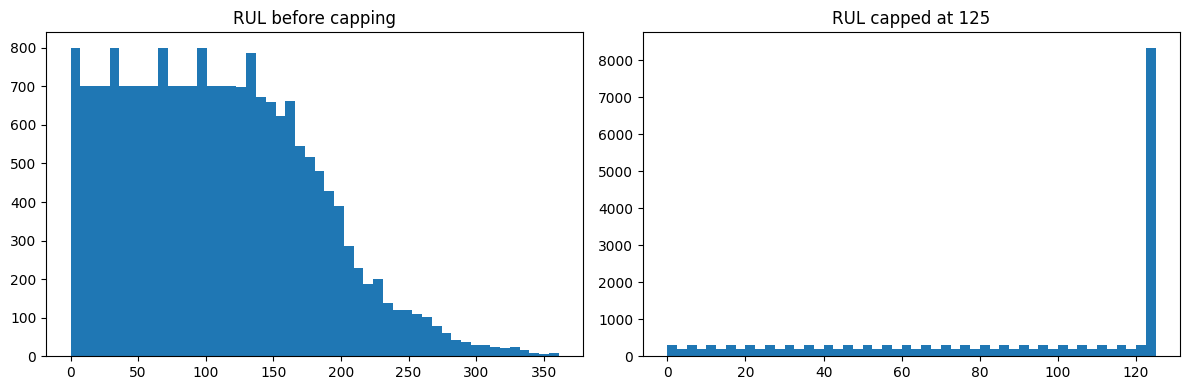

In [12]:
df_capped = train_df.copy()
df_capped["RUL"] = df_capped["RUL"].clip(upper=RUL_CAP)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["RUL"], bins=50)
axes[0].set_title("RUL before capping")
axes[1].hist(df_capped["RUL"], bins=50)
axes[1].set_title(f"RUL capped at {RUL_CAP}")
plt.tight_layout()
plt.show()


In [13]:
def normalize_hybrid(df):
    """
    Global MinMaxScaler for s3 (preserves cross-engine variance).
    Per-engine MinMaxScaler for all other features.
    Saves scalers to disk for test set preprocessing (no leakage).
    """
    df = df.copy()

    # Step 1: global scaling for s3
    global_scaler = MinMaxScaler()
    df[GLOBAL_SCALE_FEATURES] = global_scaler.fit_transform(df[GLOBAL_SCALE_FEATURES])

    # Step 2: per-engine scaling for remaining features
    scaled_parts   = []
    engine_scalers = {}

    for engine_id, group in df.groupby("engine_id"):
        scaler = MinMaxScaler()
        group  = group.copy()
        group[PER_ENGINE_FEATURES] = scaler.fit_transform(group[PER_ENGINE_FEATURES])
        engine_scalers[engine_id]  = scaler
        scaled_parts.append(group)

    df_scaled = pd.concat(scaled_parts).sort_values(
        ["engine_id", "cycle"]
    ).reset_index(drop=True)

    return df_scaled, global_scaler, engine_scalers


df_norm, global_scaler, engine_scalers = normalize_hybrid(df_capped)

# verify all values in [0,1]
check = df_norm.groupby("engine_id")[FEATURE_COLS].agg(["min", "max"])
print("Any value outside [0,1]?", ((check < -0.01) | (check > 1.01)).any().any())
print(f"s3 global std after scaling : {df_norm['s3'].std():.4f}  (should be > 0.01)")


Any value outside [0,1]? False
s3 global std after scaling : 0.1337  (should be > 0.01)


In [14]:
joblib.dump(global_scaler,  DATA_DIR / "global_scaler.pkl")
joblib.dump(engine_scalers, DATA_DIR / "engine_scalers.pkl")

print(f"Saved global_scaler.pkl  -> {DATA_DIR}")
print(f"Saved engine_scalers.pkl -> {DATA_DIR}")
print(f"Engine scalers count     : {len(engine_scalers)}")


Saved global_scaler.pkl  -> ..\data\processed\FD001
Saved engine_scalers.pkl -> ..\data\processed\FD001
Engine scalers count     : 100


In [15]:
def make_windows(df, window_size=30, stride=1):
    X, y = [], []
    for _, group in df.groupby("engine_id"):
        group    = group.sort_values("cycle")
        features = group[FEATURE_COLS].values
        labels   = group["RUL"].values
        for start in range(0, len(group) - window_size + 1, stride):
            end = start + window_size
            X.append(features[start:end])
            y.append(labels[end - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = make_windows(df_norm, window_size=30, stride=1)
print(f"X shape   : {X.shape}")    # should be (N, 30, 16)
print(f"y shape   : {y.shape}")
print(f"y min/max : {y.min():.1f} / {y.max():.1f}")


X shape   : (17731, 30, 16)
y shape   : (17731,)
y min/max : 0.0 / 125.0


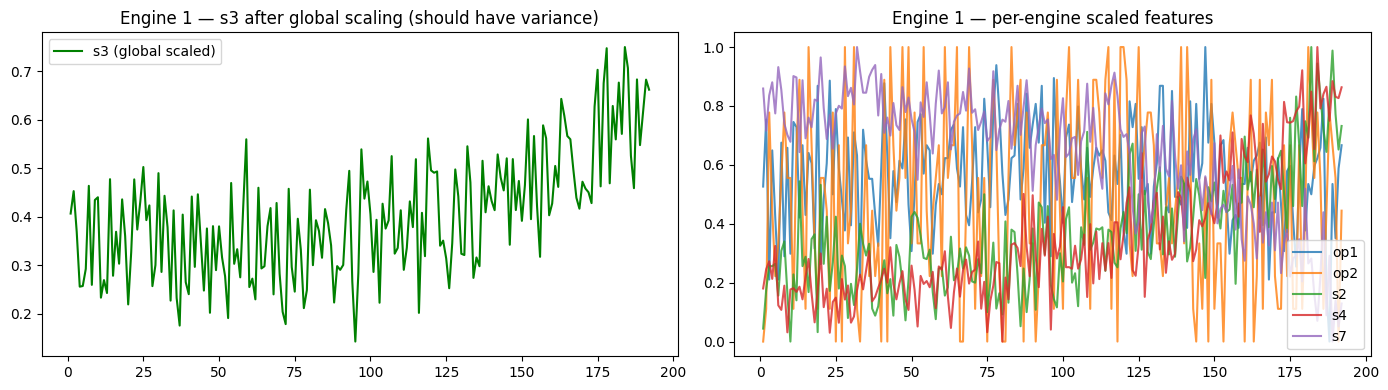

In [16]:
engine_1 = df_norm[df_norm["engine_id"] == 1].sort_values("cycle")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(engine_1["cycle"].values, engine_1["s3"].values,
             label="s3 (global scaled)", color="green")
axes[0].set_title("Engine 1 — s3 after global scaling (should have variance)")
axes[0].legend()

for col in ["op1","op2","s2","s4","s7"]:
    axes[1].plot(engine_1["cycle"].values, engine_1[col].values,
                 label=col, alpha=0.8)
axes[1].set_title("Engine 1 — per-engine scaled features")
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
np.save(DATA_DIR / "X_train.npy", X)
np.save(DATA_DIR / "y_train.npy", y)
print("Saved X_train.npy and y_train.npy")
print(f"Shape: X={X.shape}, y={y.shape}")

s3_idx  = FEATURE_COLS.index("s3")
print(f"\nX s3 std across all windows : {X[:,:,s3_idx].std():.4f}  (should be > 0.01)")
print(f"INPUT_DIM is now             : {X.shape[2]}  (was 17, now 16 — op3 dropped)")

# save updated feature list for downstream notebooks
import json
feature_config = {"feature_cols": FEATURE_COLS, "input_dim": X.shape[2]}
with open(DATA_DIR / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)
print("Saved feature_config.json")


Saved X_train.npy and y_train.npy
Shape: X=(17731, 30, 16), y=(17731,)

X s3 std across all windows : 0.1222  (should be > 0.01)
INPUT_DIM is now             : 16  (was 17, now 16 — op3 dropped)
Saved feature_config.json


In [18]:
import json

config_path = Path("../configs/model_config.json")
with open(config_path) as f:
    cfg = json.load(f)

cfg["input_dim"] = X.shape[2]   # update from 17 to 16

with open(config_path, "w") as f:
    json.dump(cfg, f, indent=2)

print(f"Updated model_config.json input_dim -> {X.shape[2]}")
print(json.dumps(cfg, indent=2))


Updated model_config.json input_dim -> 16
{
  "seq_len": 30,
  "input_dim": 16,
  "hidden_dim": 48,
  "latent_dim": 48,
  "num_layers": 3,
  "num_classes": 4,
  "embed_dim": 8
}
